In [1]:
import glob
import os

# Materials included in the dataset.
MATERIALS = ["LE_1", "LE_2", "LE_3", "HE_2", "HE_3", "HE_4", "HE_5", "HE_6", "HE_7", "HE_10"]

# Map each material to its sorted list of input extxyz files.
all_files_by_mat = {m: sorted(glob.glob(f"./xyz/{m}/*.extxyz")) for m in MATERIALS}

print({m: len(v) for m, v in all_files_by_mat.items()})

{'LE_1': 75, 'LE_2': 75, 'LE_3': 75, 'HE_2': 75, 'HE_3': 75, 'HE_4': 75, 'HE_5': 75, 'HE_6': 75, 'HE_7': 75, 'HE_10': 75}


In [2]:
# cell 2 define split
# Fixed material split used throughout the workflow.
TRAIN_MATS = ["LE_1", "LE_2", "LE_3", "HE_2", "HE_3", "HE_4", "HE_5", "HE_7"]
VAL_MAT = "HE_6"
TEST_MAT = "HE_10"

train_files = [p for m in TRAIN_MATS for p in all_files_by_mat[m]]
val_files   = all_files_by_mat[VAL_MAT]
test_files  = all_files_by_mat[TEST_MAT]

print("Train files:", len(train_files), "Val files:", len(val_files), "Test files:", len(test_files))

Train files: 600 Val files: 75 Test files: 75


In [3]:
# cell 3 filename parser
import re
pat = re.compile(r'(?P<mat>[^/\\]+)__Ov(?P<Ov>\d+)__r(?P<run>\d+)__T(?P<T>\d+)K\.extxyz$')

def parse_from_path(path):
    base = os.path.basename(path)
    m = pat.search(base)
    if not m:
        raise ValueError(f"Parse failed: {base}")
    d = m.groupdict()
    return {
        "material": d["mat"],
        "Ov": int(d["Ov"]),
        "run": int(d["run"]),
        "T": int(d["T"]),
        "source_file": base
    }

In [4]:
# cell 4 write pool.extxyz

from pathlib import Path
import ase.io
from tqdm import tqdm

OUT_TRAIN = "train_pool.extxyz"
OUT_VAL   = "val_ood.extxyz"
OUT_TEST  = "test_ood.extxyz"
for f in [OUT_TRAIN, OUT_VAL, OUT_TEST]:
    Path(f).unlink(missing_ok=True)

def append_files(file_list, out_path, desc):
    written = 0
    for fp in tqdm(file_list, desc=desc):
        meta = parse_from_path(fp)
        for atoms in ase.io.iread(fp, index=":"):
            atoms.info["material"] = meta["material"]
            atoms.info["Ov"] = meta["Ov"]
            atoms.info["T"] = meta["T"]
            atoms.info["run"] = meta["run"]
            atoms.info["source_file"] = meta["source_file"]
            ase.io.write(out_path, atoms, append=True)
            written += 1
    return written

n_train = append_files(train_files, OUT_TRAIN, "Writing train_pool")
n_val   = append_files(val_files,   OUT_VAL,   "Writing val_ood")
n_test  = append_files(test_files,  OUT_TEST,  "Writing test_ood")

print("Written frames:", {"train": n_train, "val": n_val, "test": n_test, "total": n_train+n_val+n_test})

Written frames: {'train': 120000, 'val': 15000, 'test': 15000, 'total': 150000}


In [5]:
# cell 5 sanity check
import ase.io

# Read one frame to confirm metadata was written correctly.
a = next(ase.io.iread(OUT_TRAIN, index="0"))
print("Train sample info:", a.info.get("material"), a.info.get("Ov"), a.info.get("T"), a.info.get("run"))

# Keep the species list fixed for SOAP.
# Replace this with the exact full species list used in your dataset if needed.
species = sorted(["La", "Sr", "Ca", "Nd", "Y", "Gd", "Sm", "Ba", "Co", "Fe", "O"])
print("Species fixed:", species)

Train sample info: LE_1 0 300 0
Species fixed: ['Ba', 'Ca', 'Co', 'Fe', 'Gd', 'La', 'Nd', 'O', 'Sm', 'Sr', 'Y']


In [6]:
# Cell6 IPCA：Init + params
import numpy as np
import ase.io
from tqdm import tqdm
from itertools import islice
from dscribe.descriptors import SOAP
from sklearn.decomposition import IncrementalPCA

TRAIN_FILE = "train_pool.extxyz"
VAL_FILE   = "val_ood.extxyz"
TEST_FILE  = "test_ood.extxyz"

SOAP_R_CUT = 6.0
SOAP_NMAX = 8
SOAP_LMAX = 6
IPCA_COMPONENTS = 50

BATCH_SIZE = 500     
N_JOBS = 2           

def batch_iter(reader, batch_size):
    while True:
        batch = list(islice(reader, batch_size))
        if not batch:
            break
        yield batch

# Detect whether the structures are periodic from the first training frame.
a0 = next(ase.io.iread(TRAIN_FILE, index="0"))
periodic_flag = bool(np.any(a0.get_pbc()))
print("periodic_flag =", periodic_flag)

soap = SOAP(
    species=species,
    periodic=periodic_flag,
    r_cut=SOAP_R_CUT,
    n_max=SOAP_NMAX,
    l_max=SOAP_LMAX,
    average="outer",
    sparse=False
)
ipca = IncrementalPCA(n_components=IPCA_COMPONENTS, batch_size=BATCH_SIZE)
print("SOAP+IPCA ready.")

periodic_flag = True
SOAP+IPCA ready.


In [7]:
# Cell7 IPCA: Fit IPCA without extra pass for counting

import numpy as np
import ase.io
from tqdm import tqdm

# Toggle between full training pool and a random subset of raw train files.
FIT_SUBSET = False
FIT_FILE_FRAC = 1.0
FIT_SEED = 42

if FIT_SUBSET:
    rng = np.random.default_rng(FIT_SEED)
    n_total_files = len(train_files)
    n_pick = max(1, int(np.ceil(n_total_files * FIT_FILE_FRAC)))
    pick_idx = rng.choice(n_total_files, size=n_pick, replace=False)
    FIT_FILES = [train_files[i] for i in sorted(pick_idx)]
    print(f"[IPCA FIT] SUBSET mode: {len(FIT_FILES)}/{n_total_files} files (~{FIT_FILE_FRAC:.0%})")
else:
    FIT_FILES = None
    print("[IPCA FIT] FULL mode: fitting on train_pool.extxyz")

# Fit IncrementalPCA in a single pass.
if FIT_FILES is None:
    reader = ase.io.iread(TRAIN_FILE, index=":")
    pbar = tqdm(desc="IPCA fit (FULL train_pool)", unit="frame")
    for batch in batch_iter(reader, BATCH_SIZE):
        X = soap.create(batch, n_jobs=N_JOBS)
        ipca.partial_fit(X)
        pbar.update(len(batch))
    pbar.close()
else:
    pbar = tqdm(desc="IPCA fit (SUBSET train files)", unit="frame")
    for fp in FIT_FILES:
        reader = ase.io.iread(fp, index=":")
        for batch in batch_iter(reader, BATCH_SIZE):
            X = soap.create(batch, n_jobs=N_JOBS)
            ipca.partial_fit(X)
            pbar.update(len(batch))
    pbar.close()

print("IPCA fit done. explained_var_sum =", float(ipca.explained_variance_ratio_.sum()))

[IPCA FIT] FULL mode: fitting on train_pool.extxyz


IPCA fit done. explained_var_sum = 0.9999934869722651


In [8]:
# Cell8 IPCA Transform data and save IPCA features
import numpy as np
import ase.io
from tqdm import tqdm

# Toggle between full transform and subset transform.
TRANSFORM_SUBSET = False       
TRANSFORM_FILE_FRAC = 1.0     
TRANSFORM_SEED = 42

def sample_files(files, frac, seed):
    rng = np.random.default_rng(seed)
    n = len(files)
    k = max(1, int(np.ceil(n * frac)))
    idx = rng.choice(n, size=k, replace=False)
    return [files[i] for i in sorted(idx)]

# Transform raw extxyz files into IPCA features.If need_labels=True, also return material/T/Ov/run arrays.
def transform_files_fast(file_list, desc, need_labels=False):
    Z_chunks = []
    if need_labels:
        mats_chunks, Ts_chunks, Ovs_chunks, runs_chunks = [], [], [], []

    pbar = tqdm(desc=desc, unit="frame")
    for fp in file_list:
        meta = parse_from_path(fp)
        for batch in batch_iter(ase.io.iread(fp, index=":"), BATCH_SIZE):
            X  = soap.create(batch, n_jobs=N_JOBS)
            Zb = ipca.transform(X).astype(np.float32)
            b = len(batch)

            Z_chunks.append(Zb)
            if need_labels:
                mats_chunks.append(np.array([meta["material"]]*b, dtype=object))
                Ts_chunks.append(np.full(b, meta["T"],  dtype=np.int32))
                Ovs_chunks.append(np.full(b, meta["Ov"], dtype=np.int32))
                runs_chunks.append(np.full(b, meta["run"],dtype=np.int32))

            pbar.update(b)
    pbar.close()

    Z = np.vstack(Z_chunks)
    if need_labels:
        mats = np.concatenate(mats_chunks)
        Ts   = np.concatenate(Ts_chunks)
        Ovs  = np.concatenate(Ovs_chunks)
        runs = np.concatenate(runs_chunks)
        return Z, mats, Ts, Ovs, runs
    return Z

#  Transform a pooled extxyz file into IPCA features. If need_labels=True, labels are read from atoms.info.
def transform_pool_fast(fp, desc, need_labels=False):
    Z_chunks = []
    if need_labels:
        mats_chunks, Ts_chunks, Ovs_chunks, runs_chunks = [], [], [], []

    pbar = tqdm(desc=desc, unit="frame")
    for batch in batch_iter(ase.io.iread(fp, index=":"), BATCH_SIZE):
        X  = soap.create(batch, n_jobs=N_JOBS)
        Zb = ipca.transform(X).astype(np.float32)
        b = len(batch)

        Z_chunks.append(Zb)

        if need_labels:
            mats_chunks.append(np.array([a.info.get("material","UNKNOWN") for a in batch], dtype=object))
            Ts_chunks.append(np.array([int(a.info.get("T",-1)) for a in batch], dtype=np.int32))
            Ovs_chunks.append(np.array([int(a.info.get("Ov",-1)) for a in batch], dtype=np.int32))
            runs_chunks.append(np.array([int(a.info.get("run",-1)) for a in batch], dtype=np.int32))

        pbar.update(b)
    pbar.close()

    Z = np.vstack(Z_chunks)
    if need_labels:
        mats = np.concatenate(mats_chunks)
        Ts   = np.concatenate(Ts_chunks)
        Ovs  = np.concatenate(Ovs_chunks)
        runs = np.concatenate(runs_chunks)
        return Z, mats, Ts, Ovs, runs
    return Z

if TRANSFORM_SUBSET:
    train_list = sample_files(train_files, TRANSFORM_FILE_FRAC, TRANSFORM_SEED)
    val_list   = sample_files(val_files,   TRANSFORM_FILE_FRAC, TRANSFORM_SEED)
    test_list  = sample_files(test_files,  TRANSFORM_FILE_FRAC, TRANSFORM_SEED)

    print(f"[TRANSFORM] SUBSET files: train {len(train_list)}/{len(train_files)}, "
          f"val {len(val_list)}/{len(val_files)}, test {len(test_list)}/{len(test_files)}")

    train_Z, train_m, train_T, train_Ov, train_run = transform_files_fast(train_list, "Transform train (subset files)", need_labels=True)
    val_Z  = transform_files_fast(val_list,  "Transform val (subset files)",  need_labels=False)
    test_Z = transform_files_fast(test_list, "Transform test (subset files)", need_labels=False)

    np.save("train_ipca50_sample.npy", train_Z)
    np.save("val_ipca50_sample.npy",   val_Z)
    np.save("test_ipca50_sample.npy",  test_Z)
    np.savez("train_labels_sample.npz", material=train_m, T=train_T, Ov=train_Ov, run=train_run)

    print("Saved: *_sample.npy and train_labels_sample.npz")
    print("Shapes:", train_Z.shape, val_Z.shape, test_Z.shape)

else:
    train_Z, train_m, train_T, train_Ov, train_run = transform_pool_fast(TRAIN_FILE, "Transform train (FULL pool)", need_labels=True)
    val_Z  = transform_pool_fast(VAL_FILE,  "Transform val (FULL pool)",  need_labels=False)
    test_Z = transform_pool_fast(TEST_FILE, "Transform test (FULL pool)", need_labels=False)

    np.save("train_ipca50.npy", train_Z)
    np.save("val_ipca50.npy",   val_Z)
    np.save("test_ipca50.npy",  test_Z)
    np.savez("train_labels.npz", material=train_m, T=train_T, Ov=train_Ov, run=train_run)

    print("Saved: train_ipca50.npy / val_ipca50.npy / test_ipca50.npy / train_labels.npz")
    print("Shapes:", train_Z.shape, val_Z.shape, test_Z.shape)

Saved: train_ipca50.npy / val_ipca50.npy / test_ipca50.npy / train_labels.npz
Shapes: (120000, 50) (15000, 50) (15000, 50)


In [2]:
# Cell9 reload saved features and labels
import os, glob
import numpy as np

MODE = "full"   # "full" or "sample"
OUT_DIR = f"todo4_plots_{MODE}"
os.makedirs(OUT_DIR, exist_ok=True)

def load_Z_labels(mode="full"):
    if mode == "full":
        Z_path = "train_ipca50.npy"
        lab_path = "train_labels.npz"
        if not (os.path.exists(Z_path) and os.path.exists(lab_path)):
            raise FileNotFoundError(f"Need {Z_path} and {lab_path} to resume MODE=full.")
        Z = np.load(Z_path).astype(np.float32)
        lab = np.load(lab_path, allow_pickle=True)
        mat = lab["material"]
        T   = lab["T"].astype(int)
        Ov  = lab["Ov"].astype(int)
        print("Loaded:", Z_path, "+", lab_path)
        return Z, mat, T, Ov

    if mode == "sample":
        if os.path.exists("train_ipca50_sample.npy"):
            Z = np.load("train_ipca50_sample.npy").astype(np.float32)
            lab_path = "train_labels_sample.npz"
            if not os.path.exists(lab_path):
                raise FileNotFoundError("Found train_ipca50_sample.npy but missing train_labels_sample.npz")
            lab = np.load(lab_path, allow_pickle=True)
            mat = lab["material"]
            T   = lab["T"].astype(int)
            Ov  = lab["Ov"].astype(int)
            print("Loaded: train_ipca50_sample.npy + train_labels_sample.npz")
            return Z, mat, T, Ov

        raise FileNotFoundError("MODE=sample but cannot find train_ipca50_sample.npy")

    raise ValueError("mode must be 'full' or 'sample'")

Z, mat, T, Ov = load_Z_labels(MODE)

print("Z:", Z.shape, Z.dtype)
uniq_m, cnts = np.unique(mat, return_counts=True)
print("Materials:", {str(k): int(v) for k, v in zip(uniq_m, cnts)})
print("Unique T:", len(np.unique(T)), "range:", int(T.min()), "-", int(T.max()))
print("Unique Ov:", sorted(np.unique(Ov).tolist()))

Loaded: train_ipca50.npy + train_labels.npz
Z: (120000, 50) float32
Materials: {'HE_2': 15000, 'HE_3': 15000, 'HE_4': 15000, 'HE_5': 15000, 'HE_7': 15000, 'LE_1': 15000, 'LE_2': 15000, 'LE_3': 15000}
Unique T: 5 range: 300 - 1100
Unique Ov: [0, 3, 6, 9, 12]


Materials: {'HE_2': 15000, 'HE_3': 15000, 'HE_4': 15000, 'HE_5': 15000, 'HE_7': 15000, 'LE_1': 15000, 'LE_2': 15000, 'LE_3': 15000}
Unique T: 5 range: 300 - 1100
Unique Ov: [0, 3, 6, 9, 12]


PCA2 var sum: 0.6796504259109497


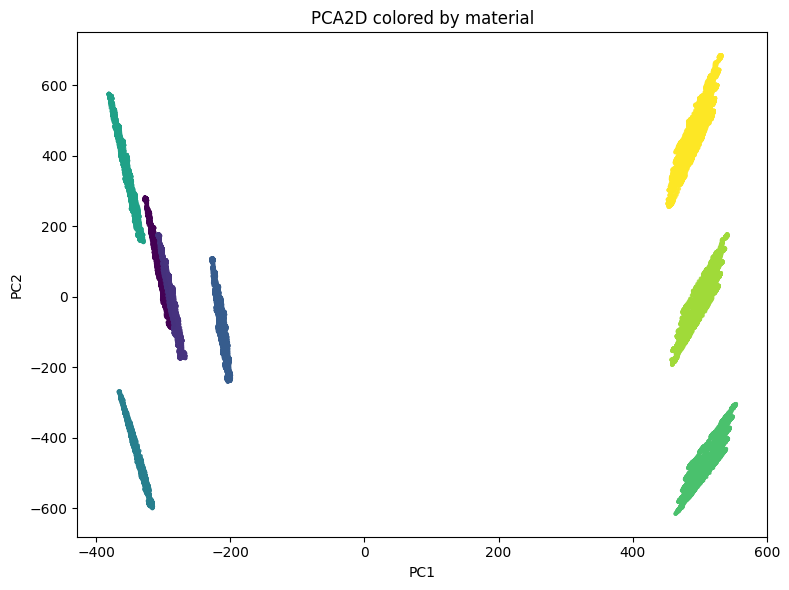

Saved: todo4_plots_full/pca2_by_material.png


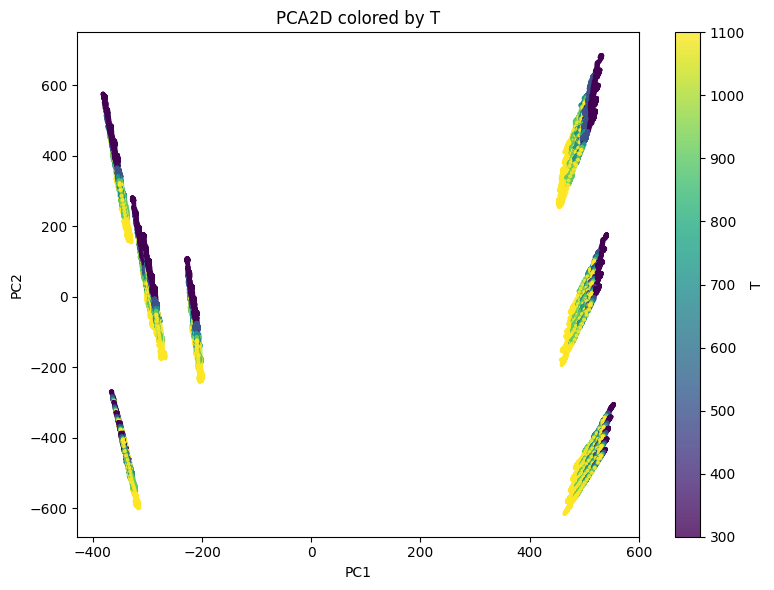

Saved: todo4_plots_full/pca2_by_T.png


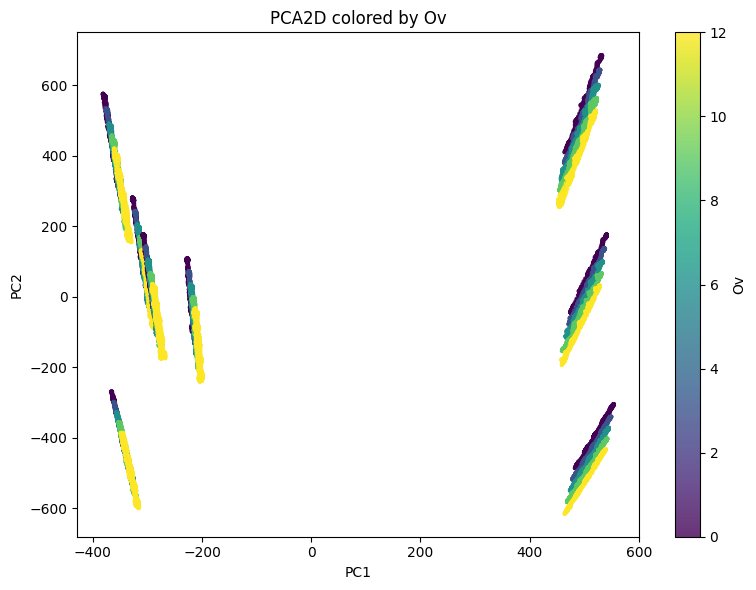

Saved: todo4_plots_full/pca2_by_Ov.png


In [4]:
# Cell 10 PCA 2D image*2

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import os

# PCA is used here only for visualization of the learned IPCA feature space.
pca2 = PCA(n_components=2, random_state=0)
P = pca2.fit_transform(Z)
print("PCA2 var sum:", float(pca2.explained_variance_ratio_.sum()))

uniq_m = np.unique(mat)
m2i = {m:i for i,m in enumerate(uniq_m)}
m_color = np.array([m2i[m] for m in mat])

def save_scatter(xy, c, title, fname, cbar_label=None):
    plt.figure(figsize=(8,6))
    plt.scatter(xy[:,0], xy[:,1], s=4, alpha=0.8, c=c)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(title)
    if cbar_label is not None:
        plt.colorbar(label=cbar_label)
    out = os.path.join(OUT_DIR, fname)
    plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
    print("Saved:", out)

save_scatter(P, m_color, "PCA2D colored by material", "pca2_by_material.png")
save_scatter(P, T, "PCA2D colored by T", "pca2_by_T.png", "T")
save_scatter(P, Ov, "PCA2D colored by Ov", "pca2_by_Ov.png", "Ov")

/home/jovyan/.py313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/jovyan/.py313/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


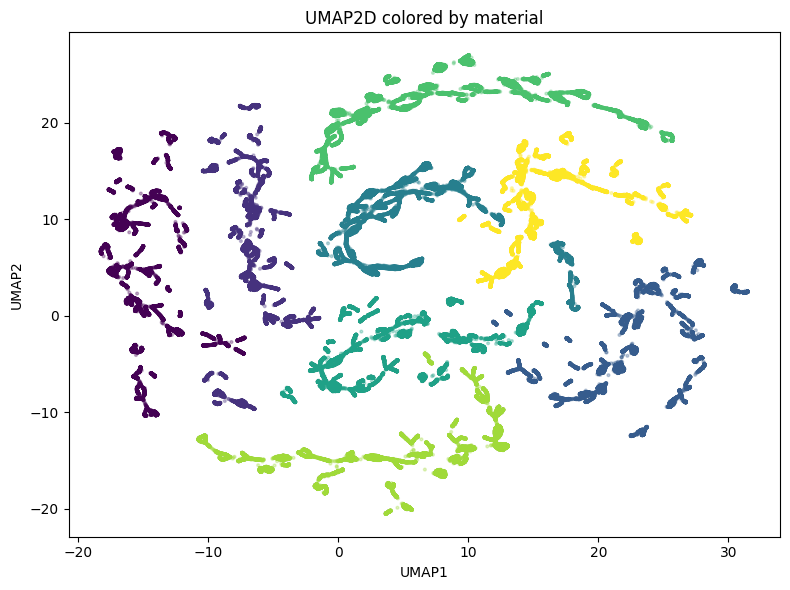

Saved: todo4_plots_full/umap_by_material.png


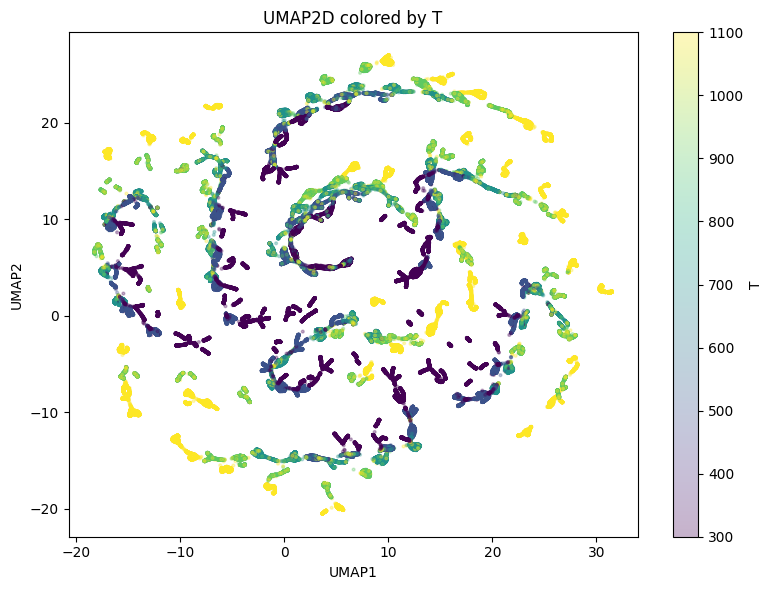

Saved: todo4_plots_full/umap_by_T.png


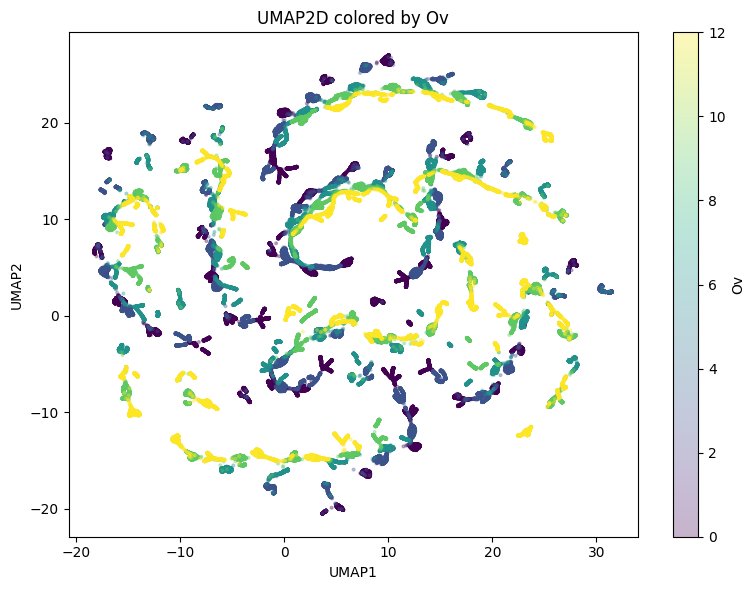

Saved: todo4_plots_full/umap_by_Ov.png


Saved: todo4_plots_full/umap_by_Ov.png


In [5]:
# Cell 11 — UMAP2D image *3

import umap
import matplotlib.pyplot as plt
import os

# UMAP provides a nonlinear 2D view of the same feature space.
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)
U = reducer.fit_transform(Z)

def save_scatter_umap(c, title, fname, cbar_label=None):
    plt.figure(figsize=(8,6))
    plt.scatter(U[:,0], U[:,1], s=4, alpha=0.3, c=c)
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title(title)
    if cbar_label is not None:
        plt.colorbar(label=cbar_label)
    out = os.path.join(OUT_DIR, fname)
    plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
    print("Saved:", out)

save_scatter_umap(m_color, "UMAP2D colored by material", "umap_by_material.png")
save_scatter_umap(T, "UMAP2D colored by T", "umap_by_T.png", "T")
save_scatter_umap(Ov, "UMAP2D colored by Ov", "umap_by_Ov.png", "Ov")

d_k stats median/p95/p99/max: 3.5738048553466797 11.894673061370847 16.519572219848623 24.012596130371094


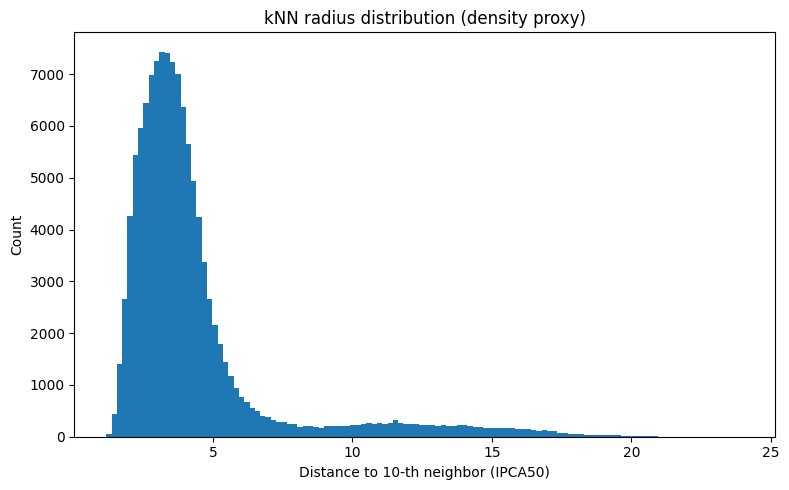

Saved: todo4_plots_full/d10_hist.png


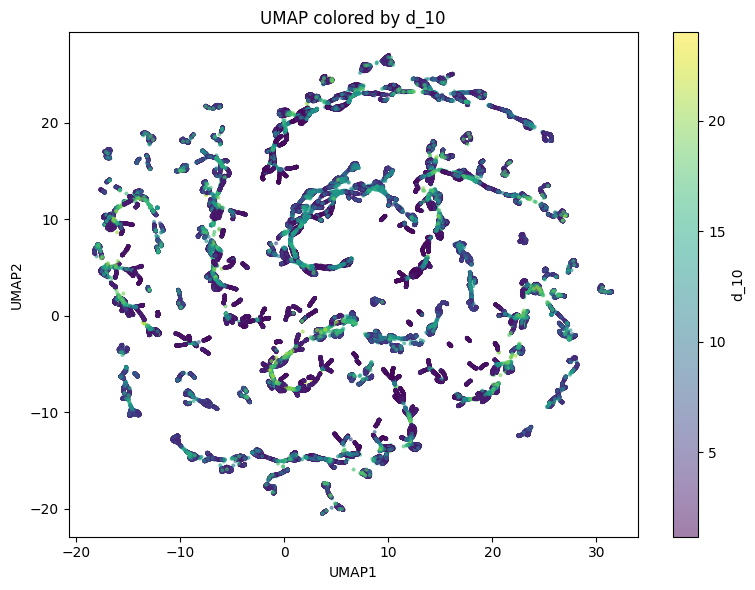

Saved: todo4_plots_full/umap_by_d10.png
mix stats median/p10/p90: 1.0 1.0 1.0


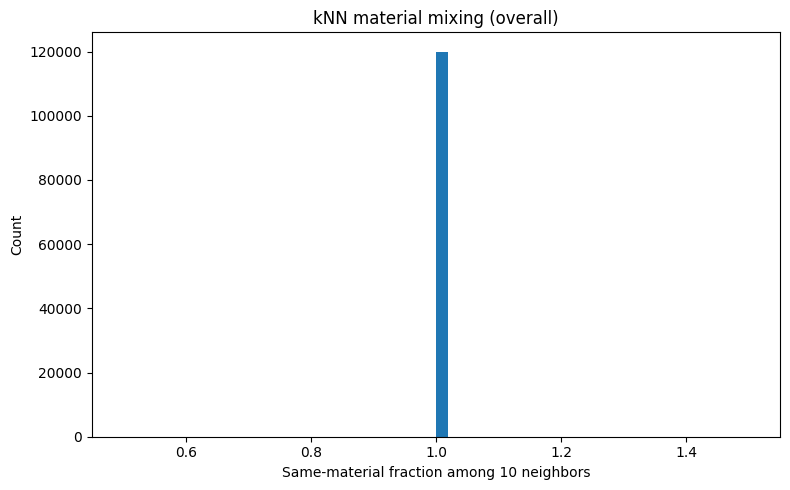

Saved: todo4_plots_full/mixing_k10_hist.png


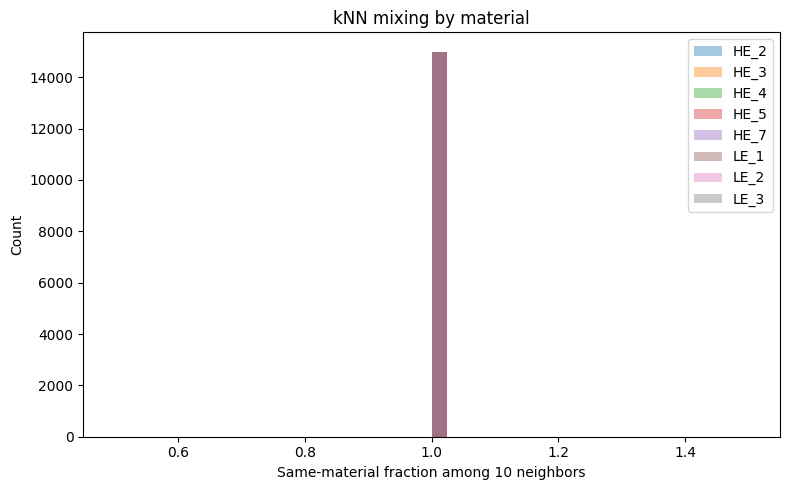

Saved: todo4_plots_full/mixing_k10_by_material.png


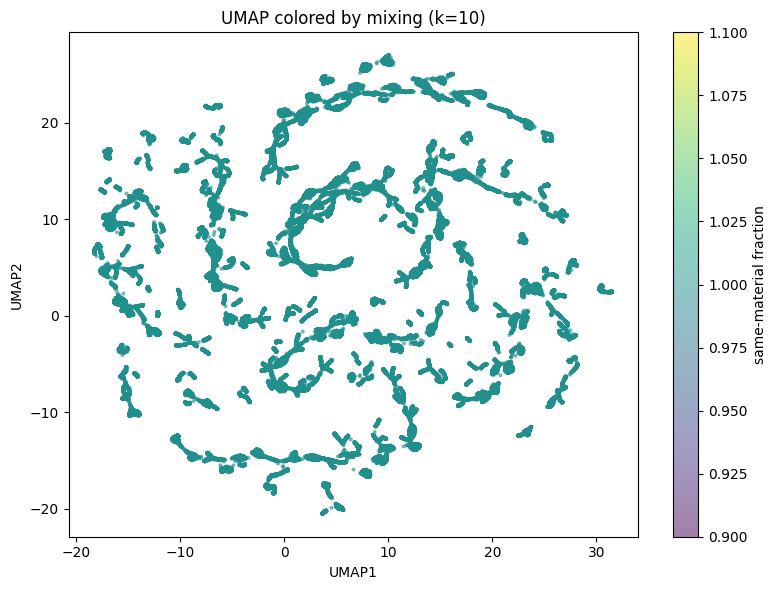

Saved: todo4_plots_full/umap_by_mixing_k10.png


In [6]:
# Cell 12 — kNN density and material mixing

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import os

k = 10
nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
dist, ind = nn.kneighbors(Z)
d_k = dist[:, k]
print("d_k stats median/p95/p99/max:", np.median(d_k), np.percentile(d_k,95), np.percentile(d_k,99), d_k.max())

# Histogram of local sparsity / density proxy.
plt.figure(figsize=(8,5))
plt.hist(d_k, bins=120)
plt.xlabel(f"Distance to {k}-th neighbor (IPCA50)")
plt.ylabel("Count")
plt.title("kNN radius distribution (density proxy)")
out = os.path.join(OUT_DIR, f"d{k}_hist.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

# Map local sparsity back onto the UMAP embedding.
plt.figure(figsize=(8,6))
plt.scatter(U[:,0], U[:,1], s=4, alpha=0.5, c=d_k)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title(f"UMAP colored by d_{k}")
plt.colorbar(label=f"d_{k}")
out = os.path.join(OUT_DIR, f"umap_by_d{k}.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

# Neighbor material mixing: fraction of same-material neighbors among the k nearest neighbors.

nbr = ind[:, 1:k+1]
mix_same_frac = (mat[nbr] == mat[:, None]).mean(axis=1)
print("mix stats median/p10/p90:", np.median(mix_same_frac), np.percentile(mix_same_frac,10), np.percentile(mix_same_frac,90))

plt.figure(figsize=(8,5))
plt.hist(mix_same_frac, bins=50)
plt.xlabel(f"Same-material fraction among {k} neighbors")
plt.ylabel("Count")
plt.title("kNN material mixing (overall)")
out = os.path.join(OUT_DIR, f"mixing_k{k}_hist.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

plt.figure(figsize=(8,5))
for m in uniq_m:
    plt.hist(mix_same_frac[mat==m], bins=40, alpha=0.4, label=str(m))
plt.xlabel(f"Same-material fraction among {k} neighbors")
plt.ylabel("Count")
plt.title("kNN mixing by material")
plt.legend()
out = os.path.join(OUT_DIR, f"mixing_k{k}_by_material.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

plt.figure(figsize=(8,6))
plt.scatter(U[:,0], U[:,1], s=4, alpha=0.5, c=mix_same_frac)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title(f"UMAP colored by mixing (k={k})")
plt.colorbar(label="same-material fraction")
out = os.path.join(OUT_DIR, f"umap_by_mixing_k{k}.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

Quota: {'HE_2': 1500, 'HE_3': 1500, 'HE_4': 1500, 'HE_5': 1500, 'HE_7': 1500, 'LE_1': 1500, 'LE_2': 1500, 'LE_3': 1500} sum= 12000
FPS selected: 12000 Random selected: 12000 Target: 12000
FPS d10 median/p10/p90: 15.0729341506958 12.145447731018066 18.405281448364256
RND d10 median/p10/p90: 8.800900936126709 5.007730865478516 14.88939151763916


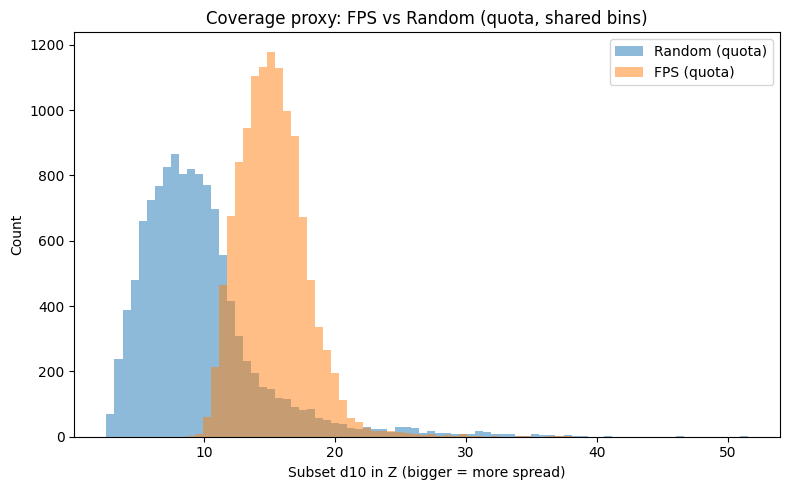

Saved: todo4_plots_full/fps_quota_vs_random_d10_hist.png

--- FPS(quota) per-material d10 ---
HE_2 n= 1500 median= 15.176758766174316 p10= 12.161069774627686
HE_3 n= 1500 median= 14.770277500152588 p10= 11.883361721038819
HE_4 n= 1500 median= 15.237762928009033 p10= 12.441803169250488
HE_5 n= 1500 median= 15.474920272827148 p10= 13.936969375610351
HE_7 n= 1500 median= 15.637202739715576 p10= 12.490895748138428
LE_1 n= 1500 median= 14.706714153289795 p10= 12.477627086639405
LE_2 n= 1500 median= 13.603894710540771 p10= 11.059805297851563
LE_3 n= 1500 median= 15.50120496749878 p10= 12.162204837799072

--- Random(quota) per-material d10 ---
HE_2 n= 1500 median= 9.199705123901367 p10= 5.377576112747192
HE_3 n= 1500 median= 8.438621997833252 p10= 5.2081389904022215
HE_4 n= 1500 median= 9.155251502990723 p10= 5.696030330657959
HE_5 n= 1500 median= 10.14149808883667 p10= 4.947417736053467
HE_7 n= 1500 median= 9.481913566589355 p10= 5.422662353515625
LE_1 n= 1500 median= 8.382065296173096 p10= 

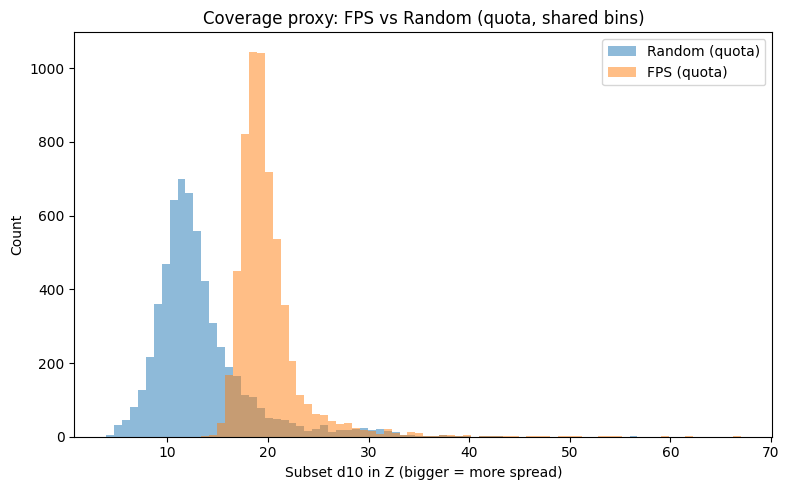

Saved: todo4_plots_full/fps_quota_vs_random_d10_hist.png

--- FPS(quota) per-material d10 ---
HE_2 n= 750 median= 19.303194999694824 p10= 17.530247116088866
HE_3 n= 750 median= 18.897645950317383 p10= 16.93191623687744
HE_4 n= 750 median= 19.44852066040039 p10= 17.28051300048828
HE_5 n= 750 median= 18.98340606689453 p10= 17.425283432006836
HE_7 n= 750 median= 19.48036766052246 p10= 17.73638858795166
LE_1 n= 750 median= 19.173124313354492 p10= 17.291687202453613
LE_2 n= 750 median= 18.385241508483887 p10= 16.407858085632324
LE_3 n= 750 median= 20.206584930419922 p10= 18.0896297454834

--- Random(quota) per-material d10 ---
HE_2 n= 750 median= 12.390615940093994 p10= 8.952939701080322
HE_3 n= 750 median= 11.826504707336426 p10= 8.242671012878418
HE_4 n= 750 median= 12.609962463378906 p10= 9.582048988342285
HE_5 n= 750 median= 13.062020301818848 p10= 10.110350322723388
HE_7 n= 750 median= 12.532806873321533 p10= 10.209815788269044
LE_1 n= 750 median= 11.764531135559082 p10= 8.345400142669

LE_3 n= 750 median= 11.986726760864258 p10= 8.583956623077393
Saved indices to todo4_plots_full


In [7]:
# Cell 13 — quota FPS vs quota random

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import os
from tqdm import tqdm

FRAC = 0.1
M = int(len(Z) * FRAC)

# Allocate a per-material quota proportional to dataset size
uniq_m, counts = np.unique(mat, return_counts=True)
counts = counts.astype(int)
raw = counts / counts.sum() * M
mi = np.floor(raw).astype(int)
remain = M - mi.sum()

if remain > 0:
    frac = raw - np.floor(raw)
    order = np.argsort(frac)[::-1]
    for i in order[:remain]:
        mi[i] += 1
quota = {m:int(k) for m,k in zip(uniq_m, mi)}
print("Quota:", quota, "sum=", sum(quota.values()))

# Greedy farthest point sampling on rows of X. Returns indices relative to X.
def fps_greedy(X, m, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    if m >= n:
        return np.arange(n, dtype=int)
    first = int(rng.integers(0, n))
    sel = [first]
    dmin = np.linalg.norm(X - X[first], axis=1)
    for _ in range(1, m):
        i = int(np.argmax(dmin))
        sel.append(i)
        dnew = np.linalg.norm(X - X[i], axis=1)
        dmin = np.minimum(dmin, dnew)
    return np.array(sel, dtype=int)

# Material-wise quota FPS.
fps_idx_list = []
for mname, mcount in quota.items():
    mask = (mat == mname)
    rel = fps_greedy(Z[mask], mcount, seed=42)
    fps_idx_list.append(np.where(mask)[0][rel])
fps_idx = np.unique(np.concatenate(fps_idx_list))

# Material-wise quota random baseline.
rng = np.random.default_rng(42)
rand_idx_list = []
for mname, mcount in quota.items():
    idxs = np.where(mat == mname)[0]
    rand_idx_list.append(rng.choice(idxs, size=mcount, replace=False))
rand_idx = np.unique(np.concatenate(rand_idx_list))

print("FPS selected:", len(fps_idx), "Random selected:", len(rand_idx), "Target:", M)

# Compute distance to the k-th nearest neighbor within a subset.
def dk_on_subset(Xsub, k=10):
    nn = NearestNeighbors(n_neighbors=k+1).fit(Xsub)
    d, _ = nn.kneighbors(Xsub)
    return d[:, k]

dk_fps  = dk_on_subset(Z[fps_idx],  k=10)
dk_rand = dk_on_subset(Z[rand_idx], k=10)

print("FPS d10 median/p10/p90:", np.median(dk_fps), np.percentile(dk_fps,10), np.percentile(dk_fps,90))
print("RND d10 median/p10/p90:", np.median(dk_rand), np.percentile(dk_rand,10), np.percentile(dk_rand,90))

# shared bins histogram
min_val = min(dk_rand.min(), dk_fps.min())
max_val = max(dk_rand.max(), dk_fps.max())
bins = np.linspace(min_val, max_val, 81)

plt.figure(figsize=(8,5))
plt.hist(dk_rand, bins=bins, alpha=0.5, label="Random (quota)")
plt.hist(dk_fps,  bins=bins, alpha=0.5, label="FPS (quota)")
plt.xlabel("Subset d10 in Z (bigger = more spread)")
plt.ylabel("Count")
plt.title("Coverage proxy: FPS vs Random (quota, shared bins)")
plt.legend()
out = os.path.join(OUT_DIR, "fps_quota_vs_random_d10_hist.png")
plt.tight_layout(); plt.savefig(out, dpi=200); plt.show()
print("Saved:", out)

# per-material d10 print
def per_material_d10(idx, name):
    print(f"\n--- {name} per-material d10 ---")
    for m in uniq_m:
        sel = idx[mat[idx] == m]
        if len(sel) < 50:
            print(m, "too few:", len(sel))
            continue
        d10 = dk_on_subset(Z[sel], k=10)
        print(m, "n=", len(sel), "median=", float(np.median(d10)), "p10=", float(np.percentile(d10,10)))

per_material_d10(fps_idx, "FPS(quota)")
per_material_d10(rand_idx, "Random(quota)")

np.save(os.path.join(OUT_DIR, "fps_idx.npy"), fps_idx)
np.save(os.path.join(OUT_DIR, "rand_idx.npy"), rand_idx)
print("Saved indices to", OUT_DIR)

Overlap: 1197 | overlap/FPS: 0.09975


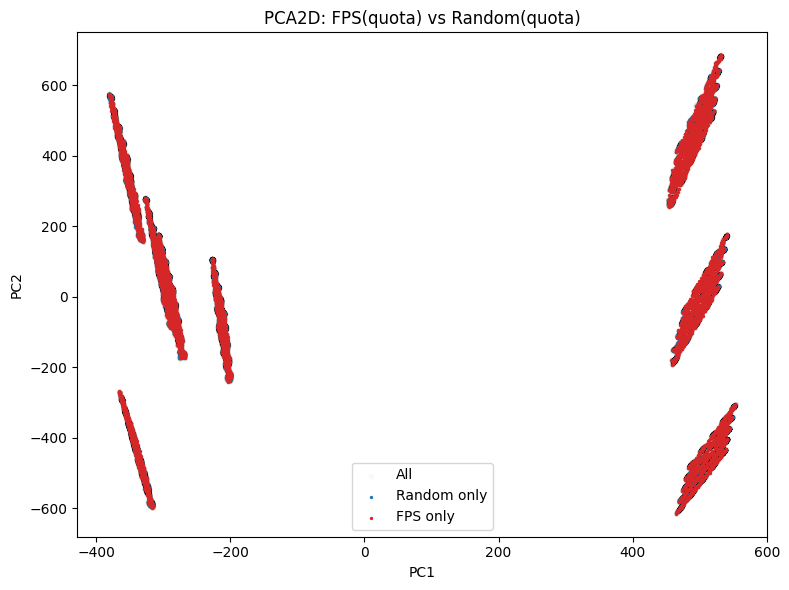

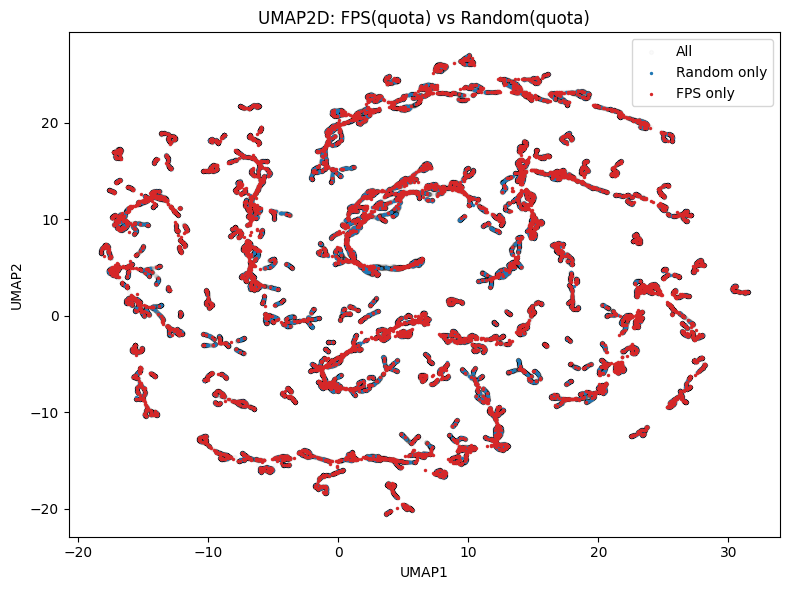

In [9]:
# Cell 14 — overlap plots for FPS vs random

import numpy as np
import matplotlib.pyplot as plt
import os

set_f = set(fps_idx.tolist())
set_r = set(rand_idx.tolist())

both = np.array(sorted(set_f & set_r), dtype=int)
fps_only = np.array(sorted(set_f - set_r), dtype=int)
rand_only = np.array(sorted(set_r - set_f), dtype=int)

print("Overlap:", len(both), "| overlap/FPS:", len(both)/len(fps_idx))

# PCA view
plt.figure(figsize=(8,6))

plt.scatter(P[:,0], P[:,1], s=8, alpha=0.02, color="black", label="All")# background
plt.scatter(P[rand_only,0], P[rand_only,1], s=2, alpha=1, color="tab:blue", label="Random only")# random
plt.scatter(P[fps_only,0], P[fps_only,1], s=2, alpha=1, color="tab:red", label="FPS only")# fps

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA2D: FPS(quota) vs Random(quota)")
plt.legend()

out = os.path.join(OUT_DIR, "pca2_fps_vs_random_quota.png")
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

# UMAP view
plt.figure(figsize=(8,6))

plt.scatter(U[:,0], U[:,1], s=8, alpha=0.02, color="black", label="All")

plt.scatter(U[rand_only,0], U[rand_only,1], s=2, alpha=1, color="tab:blue", label="Random only")

plt.scatter(U[fps_only,0], U[fps_only,1], s=2, alpha=1,
            color="tab:red",
            label="FPS only")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP2D: FPS(quota) vs Random(quota)")
plt.legend()

out = os.path.join(OUT_DIR, "umap_fps_vs_random_quota.png")
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

In [10]:
# Cell 15 —— export FPS-selected training extxyz

import ase.io
from pathlib import Path
from tqdm import tqdm
import numpy as np

if MODE == "full":
    POOL = "train_pool.extxyz"
    OUT_FPS = "train_fps.extxyz"
    total_frames = Z.shape[0] 
else:
    print("MODE=sample: fps_idx does NOT align with train_pool.extxyz. Skip export.")
    POOL = None

if POOL is not None:
    # sanity checks
    if len(fps_idx) == 0:
        raise ValueError("fps_idx is empty. Run the quota FPS cell first.")
    if int(np.max(fps_idx)) >= total_frames:
        raise ValueError(f"fps_idx max={int(np.max(fps_idx))} >= total_frames={total_frames}. "
                         "Index does not align with train_pool order.")

    Path(OUT_FPS).unlink(missing_ok=True)
    fps_set = set(fps_idx.tolist())
    written = 0

    for i, a in enumerate(tqdm(ase.io.iread(POOL, index=":"), total=total_frames, desc="Writing train_fps")):
        if i in fps_set:
            ase.io.write(OUT_FPS, a, append=True)
            written += 1

    print(f"Wrote {written} frames -> {OUT_FPS} (expected {len(fps_idx)})")
    if written != len(fps_idx):
        print("WARNING: written != len(fps_idx). Check index alignment or duplicates.")

Writing train_fps: 100%|██████████| 120000/120000 [13:43<00:00, 145.78it/s]

Wrote 12000 frames -> train_fps.extxyz (expected 12000)
